# Feature Exploration — PFO-Sec Parameter Prediction

Load cached data from `outputs/` and explore feature quality: missingness, zero-sparsity,
value ranges, correlations, and candidate columns for removal.

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

OUTPUT_DIR = Path.cwd().parent / "outputs"
print(f"Data directory: {OUTPUT_DIR}")

Data directory: c:\Users\labuser\cataverse.ai\orchestration\src\experiments\automation\outputs


---
## 1. Load Data

In [232]:
X = pd.read_parquet(OUTPUT_DIR / "X.parquet")
y = pd.read_parquet(OUTPUT_DIR / "y.parquet")

X_train = X.iloc[: int(0.8 * len(X))]
y_train = y.iloc[: int(0.8 * len(y))]
X_test = X.iloc[int(0.8 * len(X)) :]
y_test = y.iloc[int(0.8 * len(y)) :]

target_names = list(y.columns)
feature_names = list(X.columns)

print(f"X shape: {X.shape}  ({len(X)} samples, {len(feature_names)} features)")
print(f"y shape: {y.shape}  ({len(y)} samples, {len(target_names)} targets)")
print(f"Targets: {target_names}")

X shape: (232, 20)  (232 samples, 20 features)
y shape: (232, 6)  (232 samples, 6 targets)
Targets: ['pfo-sec_k_a_s-1', 'pfo-sec_q_e_au', 'pfo-sec_k_s_s-1', 'pfo-sec_k_p_s-1', 'pfo-sec_q_inf_au', 'pfo-sec_q0_au']


In [233]:
# Check for any missing values
nan_X = X.isna().sum().sum()
nan_y = y.isna().sum().sum()
print(f"NaN count — X: {nan_X}, y: {nan_y}")

if nan_X > 0:
    cols_with_nan = X.columns[X.isna().any()].tolist()
    print(f"Columns with NaN in X ({len(cols_with_nan)}): {cols_with_nan}")
if nan_y > 0:
    print(f"Rows with NaN in y:\n{y[y.isna().any(axis=1)]}")

NaN count — X: 0, y: 0


---
## 2. Feature Groups

Columns fall into logical groups. Let's enumerate them.

In [234]:
def categorize_columns(cols):
    groups = {
        "metadata": [],       # is_new, is_reference, metal_loading, exp_*
        "chain": [],          # distance_from_*, consecutive_*
        "pretreatment_num": [],  # pre_*_{duration,pressure_calc,rate,temp}
        "pretreatment_gas": [],  # pre_*_gas_*
        "prev_target": [],       # prev_pfo-sec_*
    }
    for c in cols:
        if c.startswith("prev_"):
            groups["prev_target"].append(c)
        elif c.startswith("pre_") and "_gas_" in c:
            groups["pretreatment_gas"].append(c)
        elif c.startswith("pre_"):
            groups["pretreatment_num"].append(c)
        elif c in ("is_new", "is_reference", "metal_loading"):
            groups["metadata"].append(c)
        elif c.startswith("distance_") or c.startswith("consecutive_"):
            groups["chain"].append(c)
        elif c.startswith("exp_"):
            groups["metadata"].append(c)
        else:
            groups.setdefault("other", []).append(c)
    return groups

groups = categorize_columns(feature_names)
for grp, cols in groups.items():
    print(f"{grp}: {len(cols)} columns")
    for c in cols[:5]:
        print(f"    {c}")
    if len(cols) > 5:
        print(f"    ... ({len(cols) - 5} more)")
    print()

metadata: 1 columns
    is_reference

chain: 0 columns

pretreatment_num: 6 columns
    pre_3_temp
    pre_3_duration
    pre_5_temp
    pre_5_duration
    pre_7_temp
    ... (1 more)

pretreatment_gas: 12 columns
    pre_3_gas_bit0
    pre_3_gas_bit1
    pre_3_gas_bit2
    pre_3_gas_bit3
    pre_5_gas_bit0
    ... (7 more)

prev_target: 1 columns
    prev_pfo-sec_q_e_au



---
## 3. Target Distributions

Check for zero-inflation and distribution shape.

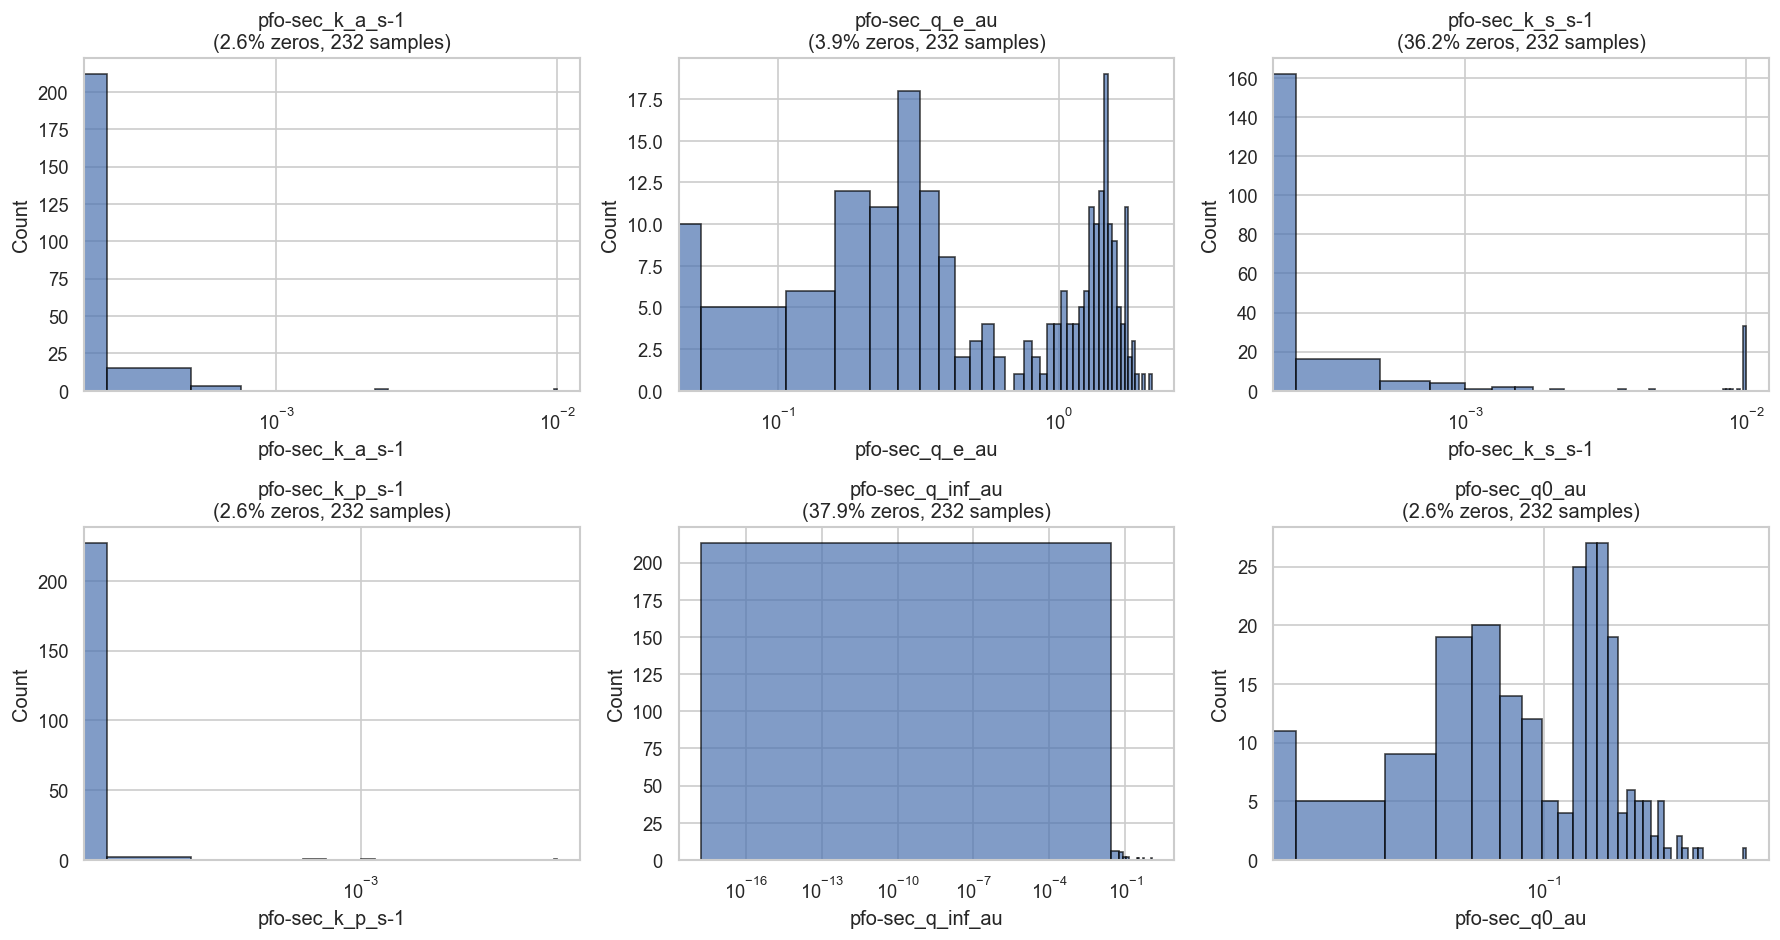

In [235]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(target_names):
    data = y[col].dropna()
    nonzero = data[data > 0]
    zero_pct = (data == 0).mean() * 100
    
    axes[i].hist(data, bins=40, edgecolor="black", alpha=0.7)
    axes[i].axvline(0, color="r", linestyle="--", alpha=0.5)
    axes[i].set_title(f"{col}\n({zero_pct:.1f}% zeros, {len(data)} samples)")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].set_xscale("log")

plt.tight_layout()
plt.show()

In [236]:
# Zero-inflation table
zero_df = pd.DataFrame({
    "target": target_names,
    "total": len(y),
    "zero_count": (y == 0).sum().values,
    "zero_pct": (y == 0).mean().values * 100,
    "min_nonzero": [y.loc[y[col] > 0, col].min() for col in target_names],
})
zero_df

,target,total,zero_count,zero_pct,min_nonzero
0,pfo-sec_k_a_s-1,232,6,2.586207,7.074790e-07
1,pfo-sec_q_e_au,232,9,3.879310,3.635078e-02
2,pfo-sec_k_s_s-1,232,84,36.206897,2.815721e-20
3,pfo-sec_k_p_s-1,232,6,2.586207,6.799951e-09
4,pfo-sec_q_inf_au,232,88,37.931034,9.803330e-17
5,pfo-sec_q0_au,232,6,2.586207,7.280823e-03


---
## 4. Feature Sparsity (Zero-Fraction)

Many columns (especially one-hot gas flags) may be almost-always-zero.

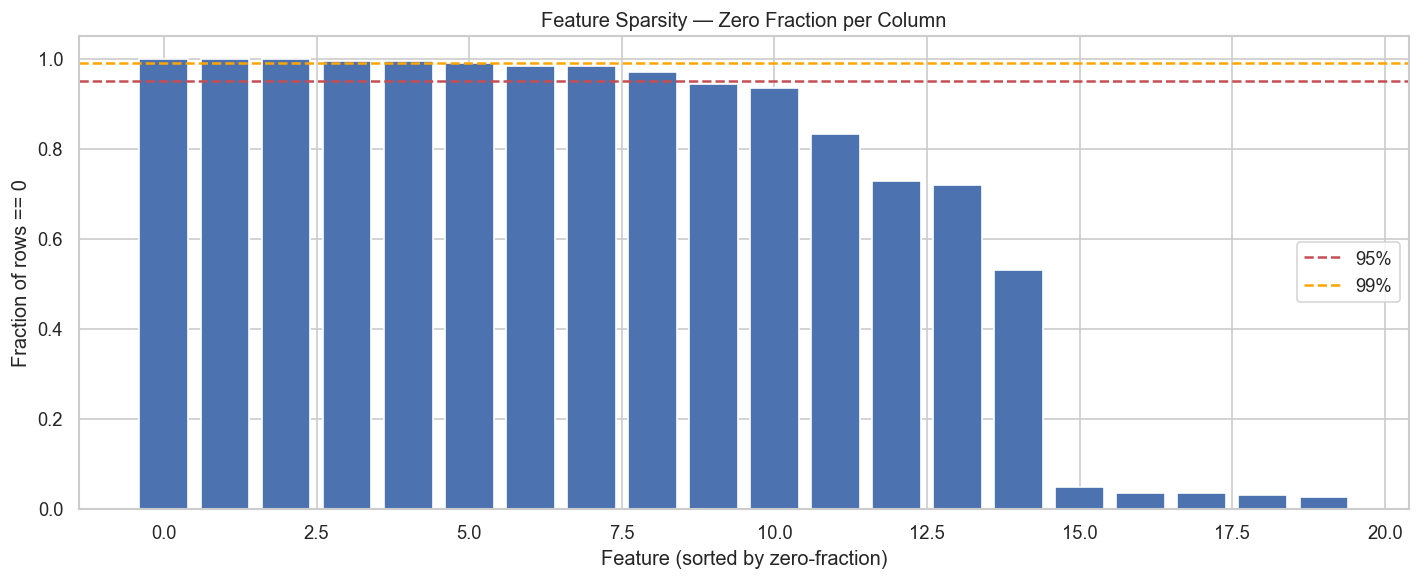

Columns with >95% zeros: 9
  100.0%  pre_3_gas_bit0
  100.0%  pre_3_gas_bit3
  100.0%  pre_7_gas_bit3
   99.6%  pre_7_gas_bit0
   99.6%  pre_7_gas_bit1
   99.1%  pre_7_gas_bit2
   98.3%  pre_7_temp
   98.3%  pre_7_duration
   97.0%  pre_5_gas_bit3


In [237]:
zero_frac = (X == 0).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(zero_frac)), zero_frac.values, width=0.8)
ax.axhline(0.95, color="r", linestyle="--", label="95%")
ax.axhline(0.99, color="orange", linestyle="--", label="99%")
ax.set_xlabel("Feature (sorted by zero-fraction)")
ax.set_ylabel("Fraction of rows == 0")
ax.set_title("Feature Sparsity — Zero Fraction per Column")
ax.legend()
plt.tight_layout()
plt.show()

# Print columns above threshold
high_sparsity = zero_frac[zero_frac > 0.95]
print(f"Columns with >95% zeros: {len(high_sparsity)}")
for col, frac in high_sparsity.items():
    print(f"  {frac*100:5.1f}%  {col}")

In [238]:
# Also check columns that are CONSTANT (single value)
nunique = X.nunique()
constant_cols = nunique[nunique <= 1]
print(f"Constant columns (single unique value): {len(constant_cols)}")
for col in constant_cols.index:
    val = X[col].iloc[0]
    print(f"  {col} = {val}")

Constant columns (single unique value): 3
  pre_3_gas_bit0 = 0.0
  pre_3_gas_bit3 = 0.0
  pre_7_gas_bit3 = 0.0


---
## 5. Feature Value Ranges by Type

In [239]:
def summarize_cols(cols, label):
    if not cols:
        print(f"\n=== {label} === (none)")
        return
    print(f"\n=== {label} === ({len(cols)} columns)")
    stats = X[cols].describe().T
    display(stats)

summarize_cols(groups["metadata"], "Metadata / Experiment Conditions")
summarize_cols(groups["chain"], "Chain Features")
summarize_cols(groups["pretreatment_num"], "Pretreatment Numeric (duration, pressure, rate, temp)")
summarize_cols(groups["pretreatment_gas"], "Pretreatment Gas One-Hot Flags")
summarize_cols(groups["prev_target"], "Previous Targets")
summarize_cols(groups.get("other", []), "Other / Uncategorized")


=== Metadata / Experiment Conditions === (1 columns)


,count,mean,std,min,25%,50%,75%,max
is_reference,232.0,0.469828,0.500168,0.0,0.0,0.0,1.0,1.0



=== Chain Features === (none)

=== Pretreatment Numeric (duration, pressure, rate, temp) === (6 columns)


,count,mean,std,min,25%,50%,75%,max
pre_3_temp,232.0,464.270903,108.246247,0.0,449.4,449.4,499.4000,749.4
pre_3_duration,232.0,1.724871,0.775483,0.0,1.0,2.0,2.0000,6.3
pre_5_temp,232.0,120.679687,214.057090,0.0,0.0,0.0,199.5500,749.4
pre_5_duration,232.0,0.327931,0.632709,0.0,0.0,0.0,0.4775,4.0
pre_7_temp,232.0,5.877825,51.298699,0.0,0.0,0.0,0.0000,664.4
pre_7_duration,232.0,0.019397,0.163335,0.0,0.0,0.0,0.0000,2.0



=== Pretreatment Gas One-Hot Flags === (12 columns)


,count,mean,std,min,25%,50%,75%,max
pre_3_gas_bit0,232.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
pre_3_gas_bit1,232.0,0.965517,0.182860,0.0,1.0,1.0,1.0,1.0
pre_3_gas_bit2,232.0,0.965517,0.182860,0.0,1.0,1.0,1.0,1.0
pre_3_gas_bit3,232.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
pre_5_gas_bit0,232.0,0.064655,0.246448,0.0,0.0,0.0,0.0,1.0
pre_5_gas_bit1,232.0,0.056034,0.230486,0.0,0.0,0.0,0.0,1.0
pre_5_gas_bit2,232.0,0.168103,0.374767,0.0,0.0,0.0,0.0,1.0
pre_5_gas_bit3,232.0,0.030172,0.171431,0.0,0.0,0.0,0.0,1.0
pre_7_gas_bit0,232.0,0.004310,0.065653,0.0,0.0,0.0,0.0,1.0
pre_7_gas_bit1,232.0,0.004310,0.065653,0.0,0.0,0.0,0.0,1.0



=== Previous Targets === (1 columns)


,count,mean,std,min,25%,50%,75%,max
prev_pfo-sec_q_e_au,232.0,0.930205,0.602764,0.0,0.301125,1.077536,1.449227,2.136045



=== Other / Uncategorized === (none)


---
## 6. Correlation with Targets

Which features are most predictive of each target? This is a quick
Pearson-correlation sweep (linear only, but useful for screening).

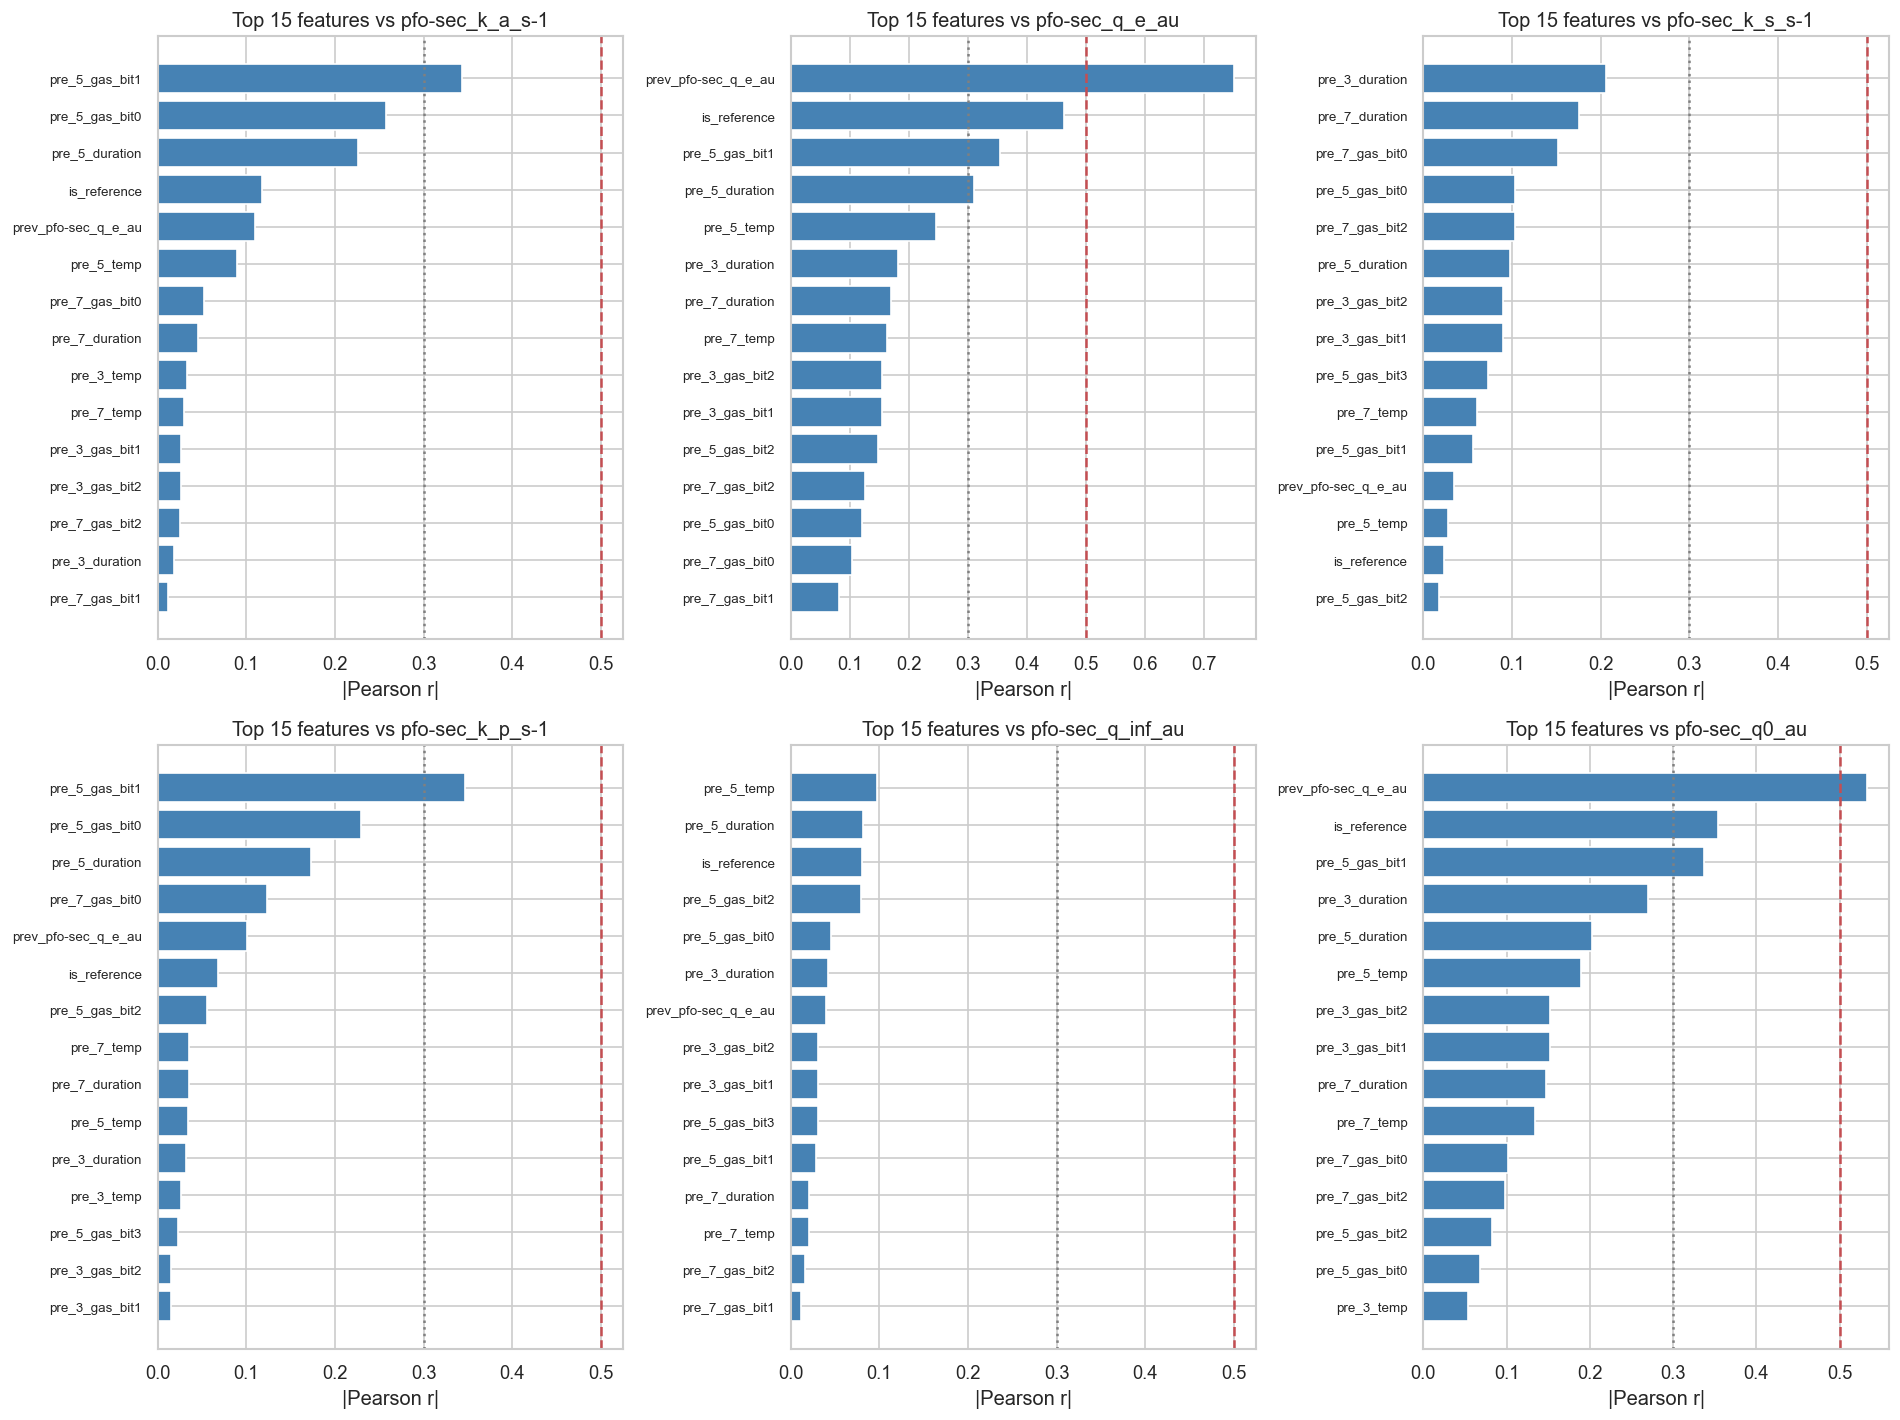

In [240]:
# Compute correlation of every feature with every target
combined = pd.concat([X, y], axis=1)
corr_matrix = combined.corr()

target_corr = corr_matrix[target_names].drop(index=target_names)

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, tgt in enumerate(target_names):
    corr_vals = target_corr[tgt].abs().sort_values(ascending=False)
    top15 = corr_vals.head(15)
    
    axes[i].barh(range(len(top15)), top15.values[::-1], color="steelblue")
    axes[i].set_yticks(range(len(top15)))
    axes[i].set_yticklabels(top15.index[::-1], fontsize=8)
    axes[i].axvline(0.3, color="gray", linestyle=":")
    axes[i].axvline(0.5, color="r", linestyle="--")
    axes[i].set_xlabel("|Pearson r|")
    axes[i].set_title(f"Top 15 features vs {tgt}")

plt.tight_layout()
plt.show()

---
## 7. Pairwise Feature Correlations

Look for highly collinear feature pairs (|r| > 0.95) that may be redundant.

In [241]:
corr_X = X.corr()

# Upper triangle mask
upper = corr_X.where(np.triu(np.ones(corr_X.shape), k=1).astype(bool))

# Find highly correlated pairs
high_pairs = []
for col in upper.columns:
    matches = upper.index[upper[col].abs() > 0.95].tolist()
    for match in matches:
        high_pairs.append((col, match, upper.loc[match, col]))

print(f"Highly correlated pairs (|r| > 0.95): {len(high_pairs)}")
print()
for c1, c2, r in sorted(high_pairs, key=lambda x: -abs(x[2])):
    print(f"  r = {r:+.4f}   {c1}  vs  {c2}")

Highly correlated pairs (|r| > 0.95): 1

  r = +1.0000   pre_3_gas_bit2  vs  pre_3_gas_bit1


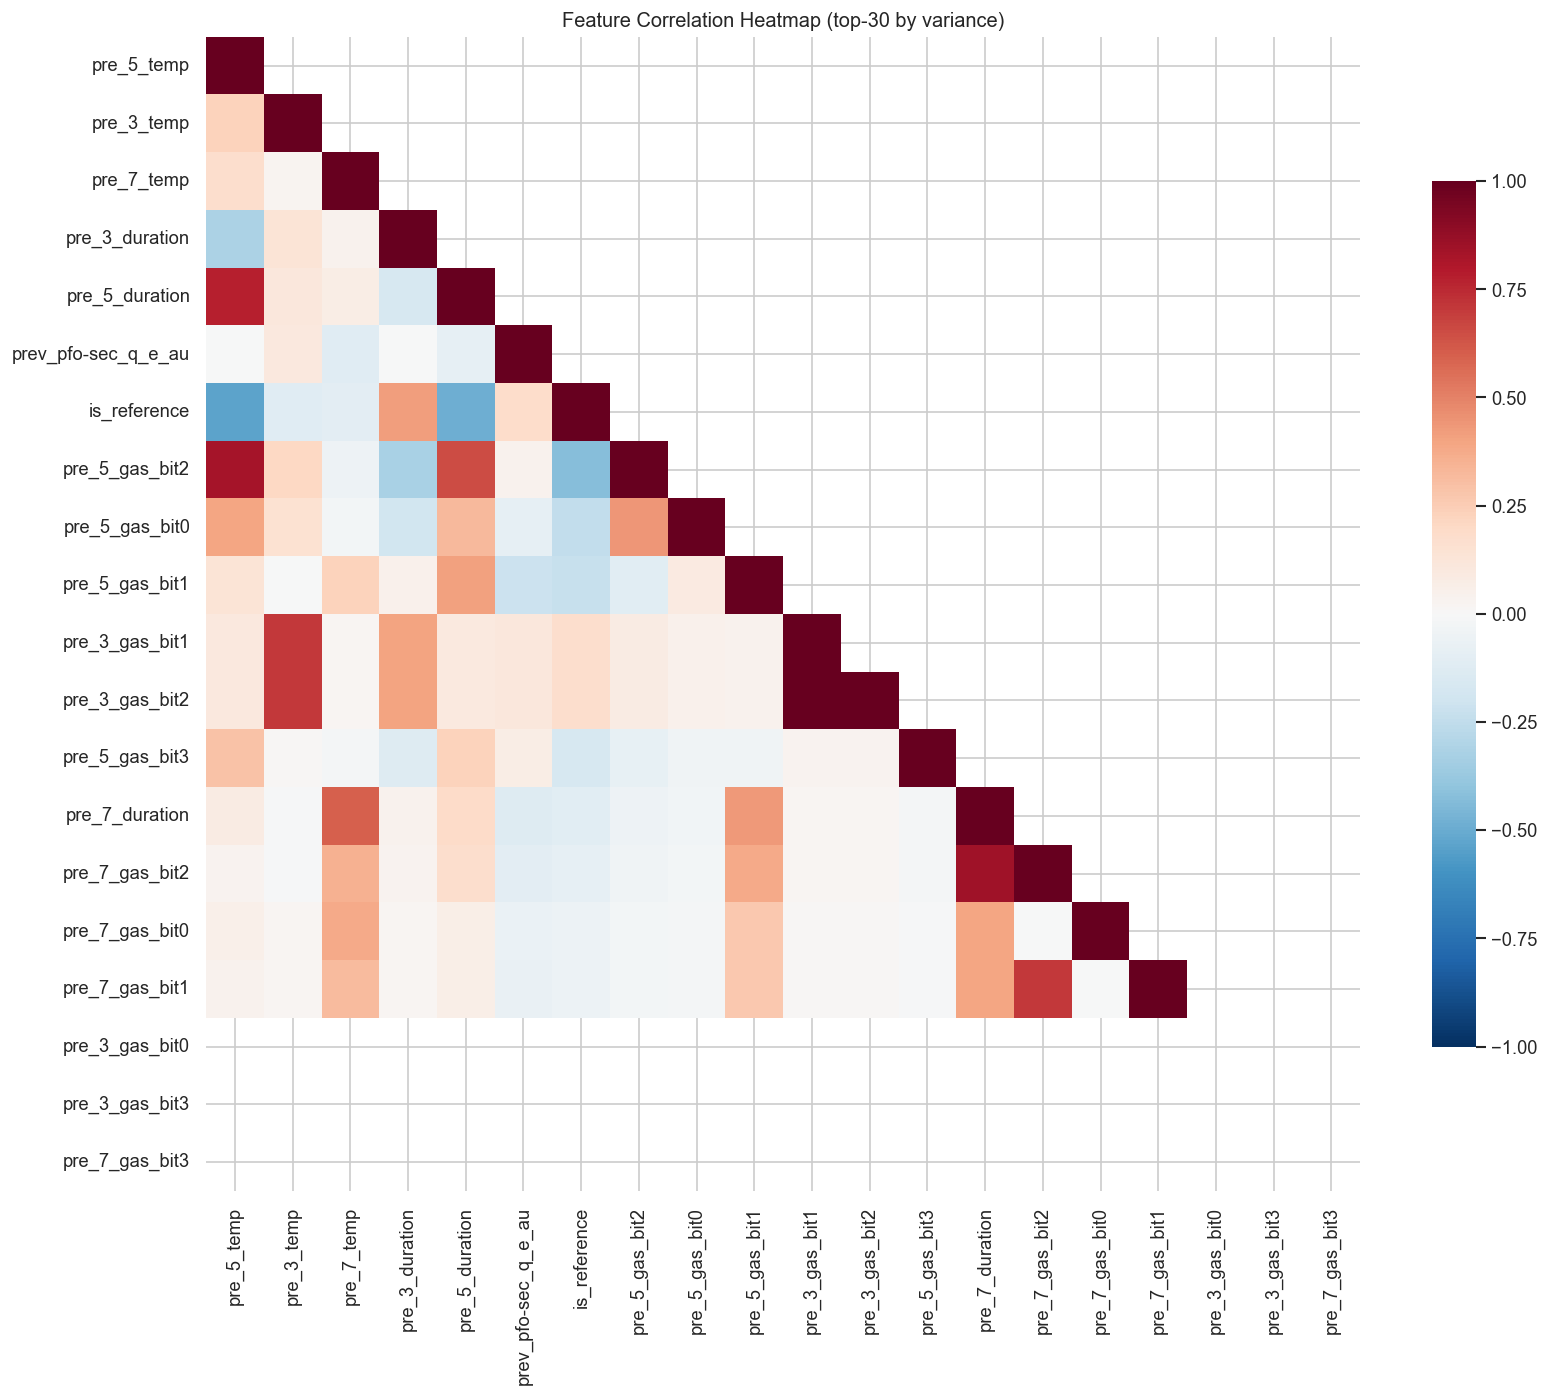

In [242]:
# Visual: correlation heatmap (too big for 126x126, so show a clustered subset)
# Pick top 30 features by variance to avoid clutter
top_var_cols = X.var().sort_values(ascending=False).head(30).index
corr_sub = X[top_var_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_sub), k=1)
sns.heatmap(corr_sub, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Feature Correlation Heatmap (top-30 by variance)")
plt.tight_layout()
plt.show()

---
## 8. Candidate Columns for Removal

Based on the above, flag columns that are:
- Constant (single value) → useless for ML
- >99% zeros → unlikely to carry signal
- Near-duplicate of another column (|r| > 0.99)

In [243]:
candidates = set()
reasons = {}

# Constant columns
for col in constant_cols.index:
    candidates.add(col)
    reasons[col] = f"constant (value={X[col].iloc[0]})"

# Near-zero-variance (>99% zeros)
near_constant = zero_frac[zero_frac > 0.99]
for col in near_constant.index:
    if col not in candidates:
        candidates.add(col)
        reasons[col] = f"{zero_frac[col]*100:.1f}% zeros"

# Near-duplicate pairs
seen = set()
for c1, c2, r in high_pairs:
    if abs(r) > 0.99:
        for col in (c1, c2):
            if col not in candidates:
                candidates.add(col)
                reasons[col] = f"|r|={abs(r):.3f} with {c2 if col==c1 else c1}"

print(f"Candidate columns for removal: {len(candidates)}")
print()
drop_df = pd.DataFrame({
    "column": sorted(candidates),
    "reason": [reasons[c] for c in sorted(candidates)],
    "zero_pct": [zero_frac.get(c, 0) * 100 for c in sorted(candidates)],
    "dtype": [X[c].dtype for c in sorted(candidates)],
})
display(drop_df)

Candidate columns for removal: 8



,column,reason,zero_pct,dtype
0,pre_3_gas_bit0,constant (value=0.0),100.000000,float64
1,pre_3_gas_bit1,|r|=1.000 with pre_3_gas_bit2,3.448276,float64
2,pre_3_gas_bit2,|r|=1.000 with pre_3_gas_bit1,3.448276,float64
3,pre_3_gas_bit3,constant (value=0.0),100.000000,float64
4,pre_7_gas_bit0,99.6% zeros,99.568966,float64
5,pre_7_gas_bit1,99.6% zeros,99.568966,float64
6,pre_7_gas_bit2,99.1% zeros,99.137931,float64
7,pre_7_gas_bit3,constant (value=0.0),100.000000,float64


---
## 9. Feature Distribution Examples

Quick histogram grid for a handful of interesting columns.

In [244]:
interesting = [
    "metal_loading", "exp_temp", "exp_pressure_calc",
    "distance_from_isnew", "distance_from_isref", "consecutive_isref",
    "pre_1_temp", "pre_8_temp",
    "pre_1_pressure_calc", "pre_8_pressure_calc",
    "pre_1_duration", "pre_8_duration",
]
interesting = [c for c in interesting if c in X.columns]

n = len(interesting)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(interesting):
    axes[i].hist(X[col].dropna(), bins=40, edgecolor="black", alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1680x0 with 0 Axes>

---
## 10. Previous-Target Features vs Actual Targets

Check how much the previous experiment's targets correlate with the current targets.

In [ ]:
prev_cols = groups["prev_target"]
if prev_cols:
    # Map prev_* to current target name
    match_counts = []
    for prev in prev_cols:
        suffix = prev.replace("prev_", "")
        if suffix in target_names:
            r = X[prev].corr(y[suffix])
            match_counts.append((suffix, r))
    
    print("Correlation of prev_target with current same target:")
    for tgt, r in match_counts:
        print(f"  {tgt}: r = {r:+.4f}")
else:
    print("No previous-target columns found.")

Correlation of prev_target with current same target:
  pfo-sec_q_e_au: r = +0.7496


---
## Summary

Use the cells above to decide which columns to drop before retraining.
Typical candidates: constant columns, >99% zero columns, one of each
near-duplicate pair.